# Practice Exercise — Reddit Tech Headlines

This exercise mirrors the BBC News practical task. You will:
1. Clean text data using NLTK
2. Tokenize and lemmatize
3. POS tag using spaCy
4. Extract Named Entities using spaCy NER

Each cell has a **TODO** with a hint. Try writing the code yourself before looking at the hint!

---

### Imports

In [1]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import re
import pandas as pd
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\usama\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\usama\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\usama\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Load Data

Run this cell to create the dataset. These are fictional but realistic tech news headlines.

In [2]:
headlines = [
    ("Apple unveils new iPhone 15 with major camera upgrades", "2023-09-12", "Technology"),
    ("Elon Musk's Tesla announces record-breaking EV sales in Q3", "2023-10-03", "Business"),
    ("Google DeepMind wins Nobel Prize for protein structure discovery", "2023-11-01", "Science"),
    ("Microsoft acquires gaming giant Activision for $69 billion", "2023-01-18", "Business"),
    ("Meta faces record fine from EU over data privacy violations", "2023-05-22", "Technology"),
    ("NASA's Artemis mission lands astronauts on the Moon", "2023-12-11", "Science"),
    ("OpenAI releases GPT-5 with human-level reasoning capabilities", "2023-03-14", "Technology"),
    ("Amazon lays off 27,000 workers amid global economic downturn", "2023-01-05", "Business"),
    ("China bans exports of critical semiconductor materials to US", "2023-07-03", "Politics"),
    ("UK government introduces new AI safety laws after landmark summit", "2023-11-02", "Politics"),
    ("Twitter rebrands to X under Elon Musk's ownership", "2023-07-24", "Technology"),
    ("Samsung unveils foldable Galaxy Z Flip with new AI features", "2023-07-26", "Technology"),
    ("Nvidia surpasses Apple as world's most valuable company", "2023-06-13", "Business"),
    ("European Parliament passes world's first comprehensive AI Act", "2023-06-14", "Politics"),
    ("SpaceX Starship completes first successful orbital test flight", "2023-11-18", "Science"),
    ("India's Chandrayaan-3 successfully lands on the Moon's south pole", "2023-08-23", "Science"),
    ("Netflix introduces password sharing crackdown across 100 countries", "2023-05-23", "Business"),
    ("Russia launches cyberattack on Ukrainian power grid infrastructure", "2023-02-14", "Politics"),
    ("Apple becomes first company to reach $3 trillion market cap", "2023-06-30", "Business"),
    ("WHO declares end of Covid-19 global health emergency", "2023-05-05", "Health"),
    ("ChatGPT reaches 100 million users faster than any app in history", "2023-02-01", "Technology"),
    ("UK enters recession as inflation hits 40-year high", "2023-02-15", "Business"),
    ("Zelensky visits Washington to seek more military aid from Biden", "2023-12-12", "Politics"),
    ("Scientists discover new antibiotic that kills drug-resistant bacteria", "2023-12-20", "Science"),
    ("TikTok faces US ban as Congress votes on national security bill", "2023-03-23", "Politics"),
    ("Boeing 737 Max grounded again after new safety concerns emerge", "2023-08-30", "Business"),
    ("OpenAI fires and rehires CEO Sam Altman after board revolt", "2023-11-21", "Technology"),
    ("Germany shuts down last nuclear power plants amid energy crisis", "2023-04-15", "Politics"),
    ("FIFA announces Saudi Arabia as 2034 World Cup host", "2023-10-04", "Sports"),
    ("England's Lionesses reach World Cup final for first time in history", "2023-08-16", "Sports"),
]

data = pd.DataFrame(headlines, columns=['title', 'date', 'category'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     30 non-null     object
 1   date      30 non-null     object
 2   category  30 non-null     object
dtypes: object(3)
memory usage: 852.0+ bytes


In [3]:
data.head()

,title,date,category
0,Apple unveils new iPhone 15 with major camera ...,2023-09-12,Technology
1,Elon Musk's Tesla announces record-breaking EV...,2023-10-03,Business
2,Google DeepMind wins Nobel Prize for protein s...,2023-11-01,Science
3,Microsoft acquires gaming giant Activision for...,2023-01-18,Business
4,Meta faces record fine from EU over data priva...,2023-05-22,Technology


### Step 1 — Extract just the titles

Just like the BBC notebook extracted only the `title` column into a new DataFrame.

In [5]:
titles = pd.DataFrame(data['title'])

titles.head()

,title
0,Apple unveils new iPhone 15 with major camera ...
1,Elon Musk's Tesla announces record-breaking EV...
2,Google DeepMind wins Nobel Prize for protein s...
3,Microsoft acquires gaming giant Activision for...
4,Meta faces record fine from EU over data priva...


### Step 2 — Lowercase

In [6]:
titles['lowercase'] = data['title'].str.lower()

titles.head()

,title,lowercase
0,Apple unveils new iPhone 15 with major camera ...,apple unveils new iphone 15 with major camera ...
1,Elon Musk's Tesla announces record-breaking EV...,elon musk's tesla announces record-breaking ev...
2,Google DeepMind wins Nobel Prize for protein s...,google deepmind wins nobel prize for protein s...
3,Microsoft acquires gaming giant Activision for...,microsoft acquires gaming giant activision for...
4,Meta faces record fine from EU over data priva...,meta faces record fine from eu over data priva...


### Step 3 — Remove Stopwords

In [10]:
en_stopwords = stopwords.words('english')

titles['no_stopwords'] = titles['lowercase'].apply(lambda x: ' '.join(word for word in x.split() if word not in en_stopwords))

titles.head()

,title,lowercase,no_stopwords
0,Apple unveils new iPhone 15 with major camera ...,apple unveils new iphone 15 with major camera ...,apple unveils new iphone 15 major camera upgrades
1,Elon Musk's Tesla announces record-breaking EV...,elon musk's tesla announces record-breaking ev...,elon musk's tesla announces record-breaking ev...
2,Google DeepMind wins Nobel Prize for protein s...,google deepmind wins nobel prize for protein s...,google deepmind wins nobel prize protein struc...
3,Microsoft acquires gaming giant Activision for...,microsoft acquires gaming giant activision for...,microsoft acquires gaming giant activision $69...
4,Meta faces record fine from EU over data priva...,meta faces record fine from eu over data priva...,meta faces record fine eu data privacy violations


### Step 4 — Remove Punctuation

In [11]:
titles['no_stopwords_no_punct'] = titles['no_stopwords'].apply(lambda x: re.sub("[^\w\s]","",x))

titles.head()

,title,lowercase,no_stopwords,no_stopwords_no_punct
0,Apple unveils new iPhone 15 with major camera ...,apple unveils new iphone 15 with major camera ...,apple unveils new iphone 15 major camera upgrades,apple unveils new iphone 15 major camera upgrades
1,Elon Musk's Tesla announces record-breaking EV...,elon musk's tesla announces record-breaking ev...,elon musk's tesla announces record-breaking ev...,elon musks tesla announces recordbreaking ev s...
2,Google DeepMind wins Nobel Prize for protein s...,google deepmind wins nobel prize for protein s...,google deepmind wins nobel prize protein struc...,google deepmind wins nobel prize protein struc...
3,Microsoft acquires gaming giant Activision for...,microsoft acquires gaming giant activision for...,microsoft acquires gaming giant activision $69...,microsoft acquires gaming giant activision 69 ...
4,Meta faces record fine from EU over data priva...,meta faces record fine from eu over data priva...,meta faces record fine eu data privacy violations,meta faces record fine eu data privacy violations


### Step 5 — Tokenize

Create two token columns — one from the raw title (for POS tagging), one from the cleaned title.

In [12]:
titles['tokens_raw'] = titles['title'].apply(lambda x: word_tokenize(x))

titles['tokens_clean'] = titles["no_stopwords_no_punct"].apply(lambda x: word_tokenize(x))

titles.head()

,title,lowercase,no_stopwords,no_stopwords_no_punct,tokens_raw,tokens_clean
0,Apple unveils new iPhone 15 with major camera ...,apple unveils new iphone 15 with major camera ...,apple unveils new iphone 15 major camera upgrades,apple unveils new iphone 15 major camera upgrades,"[Apple, unveils, new, iPhone, 15, with, major,...","[apple, unveils, new, iphone, 15, major, camer..."
1,Elon Musk's Tesla announces record-breaking EV...,elon musk's tesla announces record-breaking ev...,elon musk's tesla announces record-breaking ev...,elon musks tesla announces recordbreaking ev s...,"[Elon, Musk, 's, Tesla, announces, record-brea...","[elon, musks, tesla, announces, recordbreaking..."
2,Google DeepMind wins Nobel Prize for protein s...,google deepmind wins nobel prize for protein s...,google deepmind wins nobel prize protein struc...,google deepmind wins nobel prize protein struc...,"[Google, DeepMind, wins, Nobel, Prize, for, pr...","[google, deepmind, wins, nobel, prize, protein..."
3,Microsoft acquires gaming giant Activision for...,microsoft acquires gaming giant activision for...,microsoft acquires gaming giant activision $69...,microsoft acquires gaming giant activision 69 ...,"[Microsoft, acquires, gaming, giant, Activisio...","[microsoft, acquires, gaming, giant, activisio..."
4,Meta faces record fine from EU over data priva...,meta faces record fine from eu over data priva...,meta faces record fine eu data privacy violations,meta faces record fine eu data privacy violations,"[Meta, faces, record, fine, from, EU, over, da...","[meta, faces, record, fine, eu, data, privacy,..."


### Step 6 — Lemmatize

In [14]:
lemmatizer = WordNetLemmatizer()

titles['tokens_clean_lemmatized'] = titles["tokens_clean"].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

titles.head()

,title,lowercase,no_stopwords,no_stopwords_no_punct,tokens_raw,tokens_clean,tokens_clean_lemmatized
0,Apple unveils new iPhone 15 with major camera ...,apple unveils new iphone 15 with major camera ...,apple unveils new iphone 15 major camera upgrades,apple unveils new iphone 15 major camera upgrades,"[Apple, unveils, new, iPhone, 15, with, major,...","[apple, unveils, new, iphone, 15, major, camer...","[apple, unveils, new, iphone, 15, major, camer..."
1,Elon Musk's Tesla announces record-breaking EV...,elon musk's tesla announces record-breaking ev...,elon musk's tesla announces record-breaking ev...,elon musks tesla announces recordbreaking ev s...,"[Elon, Musk, 's, Tesla, announces, record-brea...","[elon, musks, tesla, announces, recordbreaking...","[elon, musk, tesla, announces, recordbreaking,..."
2,Google DeepMind wins Nobel Prize for protein s...,google deepmind wins nobel prize for protein s...,google deepmind wins nobel prize protein struc...,google deepmind wins nobel prize protein struc...,"[Google, DeepMind, wins, Nobel, Prize, for, pr...","[google, deepmind, wins, nobel, prize, protein...","[google, deepmind, win, nobel, prize, protein,..."
3,Microsoft acquires gaming giant Activision for...,microsoft acquires gaming giant activision for...,microsoft acquires gaming giant activision $69...,microsoft acquires gaming giant activision 69 ...,"[Microsoft, acquires, gaming, giant, Activisio...","[microsoft, acquires, gaming, giant, activisio...","[microsoft, acquires, gaming, giant, activisio..."
4,Meta faces record fine from EU over data priva...,meta faces record fine from eu over data priva...,meta faces record fine eu data privacy violations,meta faces record fine eu data privacy violations,"[Meta, faces, record, fine, from, EU, over, da...","[meta, faces, record, fine, eu, data, privacy,...","[meta, face, record, fine, eu, data, privacy, ..."


### Step 7 — Flatten token lists

Combine all token lists into single flat lists — one for raw tokens, one for clean lemmatized tokens.

In [15]:
tokens_raw_list = sum(titles['tokens_raw'],[])
tokens_clean_list = sum(titles['tokens_clean_lemmatized'],[])

print(f"Total raw tokens: {len(tokens_raw_list)}")
print(f"Total clean tokens: {len(tokens_clean_list)}")

Total raw tokens: 281
Total clean tokens: 229


---
## POS Tagging

Now we use spaCy to tag each token with its part of speech.

We use **raw tokens** for POS tagging — capitals and punctuation help spaCy identify tags more accurately.

In [16]:
nlp = spacy.load('en_core_web_sm')

In [18]:
spacy_doc = nlp(' '.join(tokens_raw_list))
spacy_doc

Apple unveils new iPhone 15 with major camera upgrades Elon Musk 's Tesla announces record-breaking EV sales in Q3 Google DeepMind wins Nobel Prize for protein structure discovery Microsoft acquires gaming giant Activision for $ 69 billion Meta faces record fine from EU over data privacy violations NASA 's Artemis mission lands astronauts on the Moon OpenAI releases GPT-5 with human-level reasoning capabilities Amazon lays off 27,000 workers amid global economic downturn China bans exports of critical semiconductor materials to US UK government introduces new AI safety laws after landmark summit Twitter rebrands to X under Elon Musk 's ownership Samsung unveils foldable Galaxy Z Flip with new AI features Nvidia surpasses Apple as world 's most valuable company European Parliament passes world 's first comprehensive AI Act SpaceX Starship completes first successful orbital test flight India 's Chandrayaan-3 successfully lands on the Moon 's south pole Netflix introduces password sharing

In [19]:
pos_df = pd.DataFrame(columns=['token', 'pos_tag'])

for token in spacy_doc:
    pos_df = pd.concat([pos_df,pd.DataFrame.from_records([{"token" : token.text , "pos_tag" : token.pos_}])],ignore_index= True)

In [20]:
pos_df.head(15)

,token,pos_tag
0,Apple,PROPN
1,unveils,VERB
2,new,ADJ
3,iPhone,PROPN
4,15,NUM
5,with,ADP
6,major,ADJ
7,camera,NOUN
8,upgrades,NOUN
9,Elon,PROPN


In [21]:
pos_df_counts = pos_df.groupby(['token','pos_tag']).size().reset_index(name= "count").sort_values(by= "count" , ascending= False)

pos_df_counts.head(10)

,token,pos_tag,count
1,'s,PART,8
168,new,ADJ,5
2,-,PUNCT,4
172,on,ADP,4
129,first,ADJ,4
86,as,SCONJ,4
147,in,ADP,3
224,with,ADP,3
11,AI,PROPN,3
16,Apple,PROPN,3


In [39]:
nouns = pos_df_counts[pos_df_counts.pos_tag == "NOUN"]
nouns

,token,pos_tag,count
194,safety,NOUN,2
180,power,NOUN,2
142,history,NOUN,2
226,world,NOUN,2
99,company,NOUN,2
...,...,...,...
87,astronauts,NOUN,1
88,bacteria,NOUN,1
89,ban,NOUN,1
92,bill,NOUN,1


In [41]:
verbs = pos_df_counts[pos_df_counts.pos_tag == "VERB"][0:10]
verbs

,token,pos_tag,count
183,reach,VERB,2
150,introduces,VERB,2
153,lands,VERB,2
82,announces,VERB,2
216,unveils,VERB,2
125,features,VERB,1
139,grounded,VERB,1
143,hits,VERB,1
151,kills,VERB,1
134,gaming,VERB,1


In [42]:
adj = pos_df_counts[pos_df_counts.pos_tag == "ADJ"][0:10]
adj

,token,pos_tag,count
168,new,ADJ,5
129,first,ADJ,4
136,global,ADJ,2
131,foldable,ADJ,1
162,military,ADJ,1
159,major,ADJ,1
126,final,ADJ,1
165,more,ADJ,1
135,giant,ADJ,1
154,last,ADJ,1


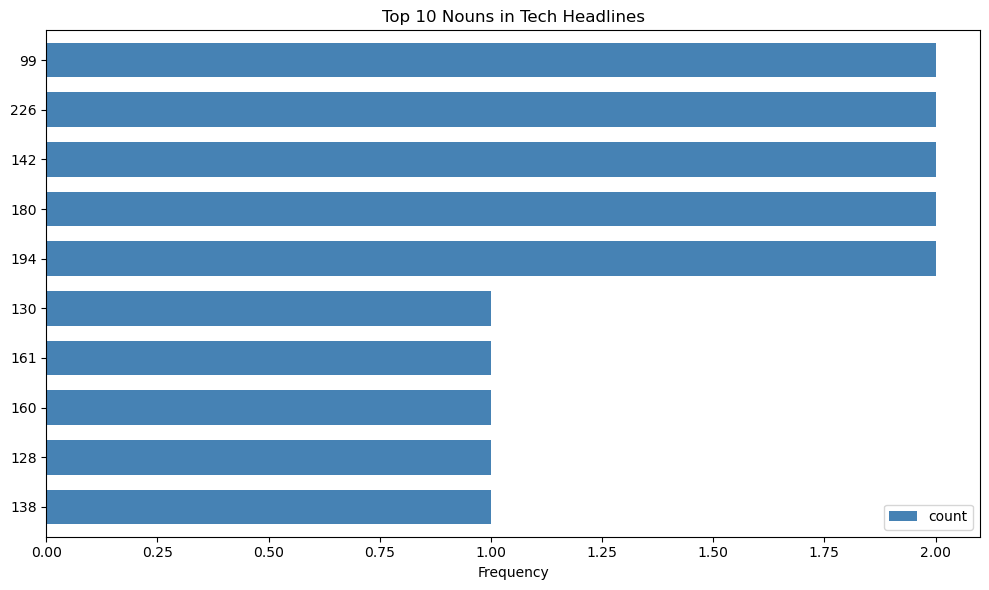

In [45]:
# TODO: Plot the top 10 nouns as a horizontal bar chart
# Hint: nouns[0:10].sort_values(by='counts').plot.barh(...)
nouns[0:10].sort_values(by='count').plot.barh(color='steelblue', width=0.7, figsize=(10, 6))
plt.title('Top 10 Nouns in Tech Headlines')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

---
## Named Entity Recognition (NER)

Now extract named entities — people, places, organisations, dates — from the headlines.

In [ ]:
ner_df = pd.DataFrame(columns=['token', 'ner_tag'])

for token in spacy_doc.ents:
    if pd.isna(token.label_) is False:
        ner_df = 

In [ ]:
ner_df.head(10)

In [ ]:
ner_df_counts = 

ner_df_counts.head(10)

In [ ]:
people = 
people

In [ ]:
places = 
places

In [ ]:
orgs = 
orgs

In [ ]:
# TODO: Plot the top 10 places as a horizontal bar chart
places.sort_values(by='counts').plot.barh(color='coral', width=0.7, figsize=(10, 6))
plt.title('Most Mentioned Places in Tech Headlines')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

---
## Bonus Challenge 1 — Category Breakdown

Filter headlines by category and find the most common nouns in **Technology** headlines only.

In [ ]:
# TODO: Filter data where category == 'Technology'
tech_titles = data[data['category'] == 'Technology']['title'].tolist()

# TODO: Join and process through spaCy
tech_doc = nlp(' '.join(tech_titles))

# TODO: Build a pos dataframe for tech headlines only and find top 5 nouns
tech_pos_df = pd.DataFrame(columns=['token', 'pos_tag'])

for token in tech_doc:
    tech_pos_df = pd.concat([tech_pos_df,
                             pd.DataFrame.from_records([{'token': token.text, 'pos_tag': token.pos_}])],
                            ignore_index=True)

tech_counts = tech_pos_df.groupby(['token','pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

print("Top 5 nouns in Technology headlines:")
print(tech_counts[tech_counts.pos_tag == 'NOUN'][0:5])

## Bonus Challenge 2 — NER Tag Distribution

Count how many different types of named entity tags appear in the data and plot them.

In [ ]:
ner_tag_counts = 

print(ner_tag_counts)

ner_tag_counts.sort_values().plot.barh(color='mediumpurple', width=0.7, figsize=(10, 6))
plt.title('Named Entity Tag Distribution')
plt.xlabel('Number of Unique Tokens')
plt.tight_layout()
plt.show()